# Feature Engineering - California Housing Dataset

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression


## Bước 0. Đọc dữ liệu & Chia Train/Test

We read the raw dataset, split into features X and target y (`median_house_value`), and perform a train/test split (80/20) with a fixed seed.

In [2]:
data = pd.read_csv('../data/raw/1553768847-housing.csv')
print(f"Raw dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")

X = data.drop(columns=['median_house_value'])
y = data[['median_house_value']]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Raw dataset shape: 20640 rows, 10 columns
X_train shape: (16512, 9), y_train shape: (16512, 1)
X_test shape: (4128, 9), y_test shape: (4128, 1)


## Bước 1. Xử Lý Giá Trị Thiếu (Handling Missing Values)

We impute missing values in `total_bedrooms` using **Median Imputation** computed from the Train set, and add a binary indicator column `total_bedrooms_isnull`.

In [3]:
# Impute missing total_bedrooms with Median of Train set
imputer = SimpleImputer(strategy='median')
X_train[['total_bedrooms']] = imputer.fit_transform(X_train[['total_bedrooms']])
X_test[['total_bedrooms']] = imputer.transform(X_test[['total_bedrooms']])

print("Missing values after imputation:")
print("  X_train missing count:", X_train['total_bedrooms'].isnull().sum())
print("  X_test missing count:", X_test['total_bedrooms'].isnull().sum())

Missing values after imputation:
  X_train missing count: 0
  X_test missing count: 0


## Bước 2. Xử Lý Giá Trị Ngoại Lệ (Handling Outliers)

We apply log1p transformation to right-skewed columns (`total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`) and apply capping using the 1.5x IQR method calculated on the training set.

In [4]:
outlier_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# 1. IQR Capping
print("Capping outliers based on training set IQR boundaries...")
for col in outlier_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Cap values on train and test
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

# 2. Log Transform
print("Applying log1p transform to right-skewed numerical columns...")
for col in outlier_cols:
    X_train[f"{col}_log"] = np.log1p(X_train[col])
    X_test[f"{col}_log"] = np.log1p(X_test[col])
    
print("Outliers handled successfully.")

Capping outliers based on training set IQR boundaries...
Applying log1p transform to right-skewed numerical columns...
Outliers handled successfully.


## Bước 3. Mã Hóa Biến Phân Loại (Categorical Encoding)

Encode the `ocean_proximity` column using One-Hot encoding.

In [5]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[['ocean_proximity']])

ohe_cols = [f"ocean_proximity_{cat}" for cat in ohe.categories_[0]]
train_ohe = pd.DataFrame(ohe.transform(X_train[['ocean_proximity']]), columns=ohe_cols, index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[['ocean_proximity']]), columns=ohe_cols, index=X_test.index)

# Concatenate
X_train = pd.concat([X_train.drop(columns=['ocean_proximity']), train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=['ocean_proximity']), test_ohe], axis=1)

print(f"Encoded X_train shape: {X_train.shape}, Encoded X_test shape: {X_test.shape}")

Encoded X_train shape: (16512, 18), Encoded X_test shape: (4128, 18)

## Bước 4: Tạo các kịch bản đặc trưng (PA1, PA2, PA3_A, PA3_B)
Chúng ta sẽ chuẩn bị dữ liệu cho 4 kịch bản đối sánh trước khi thực hiện chuẩn hóa (scaling):
- **PA1 (Base)**: Dữ liệu gốc ban đầu.
- **PA2 (Reduced)**: Bỏ Hộ gia đình và Phòng ngủ, gộp Kinh/Vĩ độ thành `coords_sum`.
- **PA3_A (Mean Aggregation)**: Gộp Kinh/Vĩ độ, gộp Room/Bed và Pop/House bằng trung bình cộng.
- **PA3_B (PCA Aggregation)**: Gộp Kinh/Vĩ độ, gộp Room/Bed/Pop/House bằng PCA 1 chiều.

In [6]:
from sklearn.decomposition import PCA

# 1. Tạo các đặc trưng gộp trung gian (chưa scale)
coords_sum_train = X_train['latitude'] + X_train['longitude']
coords_sum_test = X_test['latitude'] + X_test['longitude']

# Cặp gộp trung bình cộng cho PA3_A
rooms_bedrooms_combined_tr = (X_train['total_rooms_log'] + X_train['total_bedrooms_log']) / 2
rooms_bedrooms_combined_ts = (X_test['total_rooms_log'] + X_test['total_bedrooms_log']) / 2

pop_households_combined_tr = (X_train['population_log'] + X_train['households_log']) / 2
pop_households_combined_ts = (X_test['population_log'] + X_test['households_log']) / 2

# PCA 1 chiều cho PA3_B
collinear_cols = ['total_rooms_log', 'total_bedrooms_log', 'population_log', 'households_log']
pca_agg = PCA(n_components=1, random_state=42)
pca_tr = pca_agg.fit_transform(X_train[collinear_cols])
pca_ts = pca_agg.transform(X_test[collinear_cols])

ohe_cols = [col for col in X_train.columns if 'ocean_proximity_' in col]

# 2. Xây dựng các kịch bản đặc trưng

# PA1 (Base Features - Original)
pa1_numeric = ['longitude', 'latitude', 'housing_median_age', 
               'total_rooms_log', 'total_bedrooms_log', 'population_log', 'households_log', 'median_income_log']
X_train_pa1 = X_train[pa1_numeric + ohe_cols].copy()
X_test_pa1 = X_test[pa1_numeric + ohe_cols].copy()

# PA2 (Reduced - Drop & Coords Sum)
pa2_numeric = ['housing_median_age', 'total_rooms_log', 'population_log', 'median_income_log']
X_train_pa2 = X_train[pa2_numeric + ohe_cols].copy()
X_test_pa2 = X_test[pa2_numeric + ohe_cols].copy()
X_train_pa2['coords_sum'] = coords_sum_train
X_test_pa2['coords_sum'] = coords_sum_test
pa2_numeric.append('coords_sum')

# PA3_A (Mean Aggregation)
pa3a_numeric = ['housing_median_age', 'median_income_log']
X_train_pa3a = X_train[pa3a_numeric + ohe_cols].copy()
X_test_pa3a = X_test[pa3a_numeric + ohe_cols].copy()
X_train_pa3a['rooms_bedrooms_combined'] = rooms_bedrooms_combined_tr
X_test_pa3a['rooms_bedrooms_combined'] = rooms_bedrooms_combined_ts
X_train_pa3a['pop_households_combined'] = pop_households_combined_tr
X_test_pa3a['pop_households_combined'] = pop_households_combined_ts
X_train_pa3a['coords_sum'] = coords_sum_train
X_test_pa3a['coords_sum'] = coords_sum_test
pa3a_numeric.extend(['rooms_bedrooms_combined', 'pop_households_combined', 'coords_sum'])

# PA3_B (PCA Aggregation)
pa3b_numeric = ['housing_median_age', 'median_income_log']
X_train_pa3b = X_train[pa3b_numeric + ohe_cols].copy()
X_test_pa3b = X_test[pa3b_numeric + ohe_cols].copy()
X_train_pa3b['size_pc1'] = pca_tr
X_test_pa3b['size_pc1'] = pca_ts
X_train_pa3b['coords_sum'] = coords_sum_train
X_test_pa3b['coords_sum'] = coords_sum_test
pa3b_numeric.extend(['size_pc1', 'coords_sum'])

print("Scenarios created successfully (unscaled).")

Scenarios created successfully (unscaled).


## Bước 5: Chuẩn hóa đặc trưng (Scaling) cho từng kịch bản
Chúng ta thực hiện Standard Scaling độc lập cho từng kịch bản trên các cột số tương ứng.

In [7]:
scenarios_config = [
    ("PA1", X_train_pa1, X_test_pa1, pa1_numeric),
    ("PA2", X_train_pa2, X_test_pa2, pa2_numeric),
    ("PA3_A", X_train_pa3a, X_test_pa3a, pa3a_numeric),
    ("PA3_B", X_train_pa3b, X_test_pa3b, pa3b_numeric)
]

for name, tr_df, ts_df, num_cols in scenarios_config:
    scaler = StandardScaler()
    tr_df[num_cols] = scaler.fit_transform(tr_df[num_cols])
    ts_df[num_cols] = scaler.transform(ts_df[num_cols])

print("All scenarios scaled successfully.")

All scenarios scaled successfully.


## Bước 6: Trực quan hóa ma trận tương quan Pearson và df.head()
Kiểm tra mức độ đa cộng tuyến của từng phương án sau khi xử lý.


 SCENARIO: PA1 (Base Features - Original)


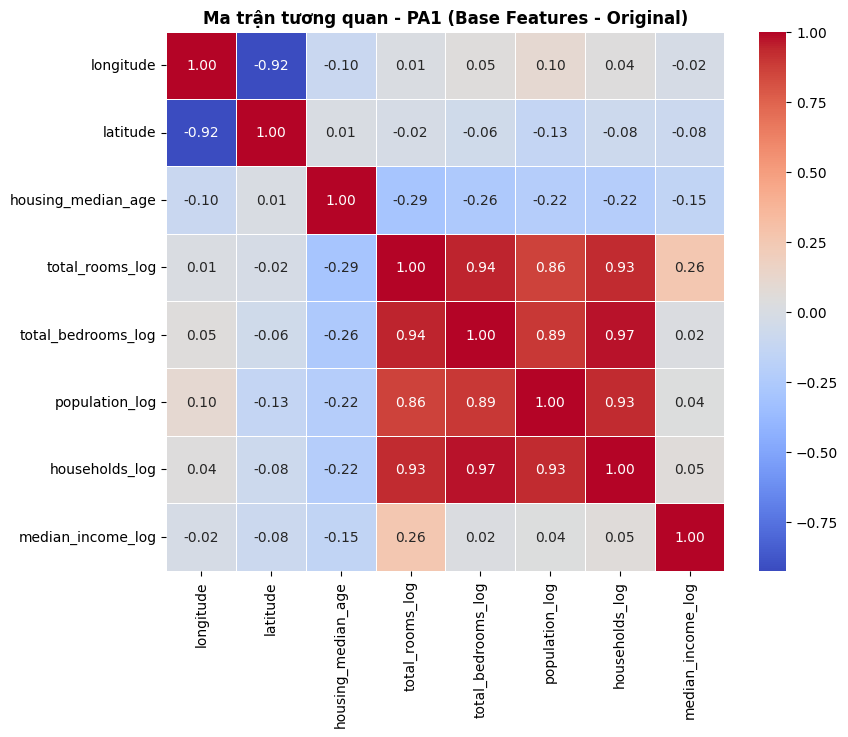

Cột đặc trưng (13): ['longitude', 'latitude', 'housing_median_age', 'total_rooms_log', 'total_bedrooms_log', 'population_log', 'households_log', 'median_income_log', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


,longitude,latitude,housing_median_age,total_rooms_log,total_bedrooms_log,population_log,households_log,median_income_log,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,1.272587,-1.372811,0.348490,0.620297,0.593051,1.051363,0.680871,-0.184340,0.0,0.0,0.0,0.0,1.0
8267,0.709162,-0.876696,1.618118,0.731749,0.924009,0.249761,0.961183,0.170161,0.0,0.0,0.0,0.0,1.0
17445,-0.447603,-0.460146,-1.952710,-0.086857,-0.336438,-0.268265,-0.212914,0.370597,0.0,0.0,0.0,0.0,1.0
14265,1.232698,-1.382172,0.586545,-0.495814,-0.186316,0.358812,-0.133342,-1.258856,0.0,0.0,0.0,0.0,1.0
2271,-0.108551,0.532084,1.142008,0.235450,0.047502,-0.333872,-0.034878,0.009915,0.0,1.0,0.0,0.0,0.0



 SCENARIO: PA2 (Drop Bedrooms & Households + Coords Sum)


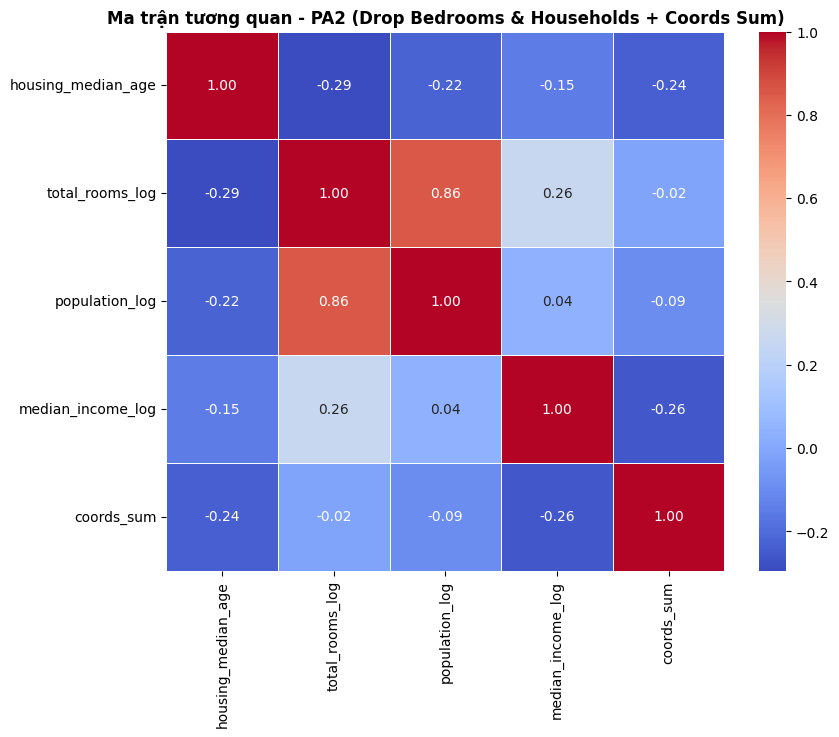

Cột đặc trưng (10): ['housing_median_age', 'total_rooms_log', 'population_log', 'median_income_log', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'coords_sum']


,housing_median_age,total_rooms_log,population_log,median_income_log,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,coords_sum
14196,0.348490,0.620297,1.051363,-0.184340,0.0,0.0,0.0,0.0,1.0,-0.467268
8267,1.618118,0.731749,0.249761,0.170161,0.0,0.0,0.0,0.0,1.0,-0.553150
17445,-1.952710,-0.086857,-0.268265,0.370597,0.0,0.0,0.0,0.0,1.0,-2.307589
14265,0.586545,-0.495814,0.358812,-1.258856,0.0,0.0,0.0,0.0,1.0,-0.589956
2271,1.142008,0.235450,-0.333872,0.009915,0.0,1.0,0.0,0.0,0.0,1.127677



 SCENARIO: PA3_A (Mean Aggregation + Coords Sum)


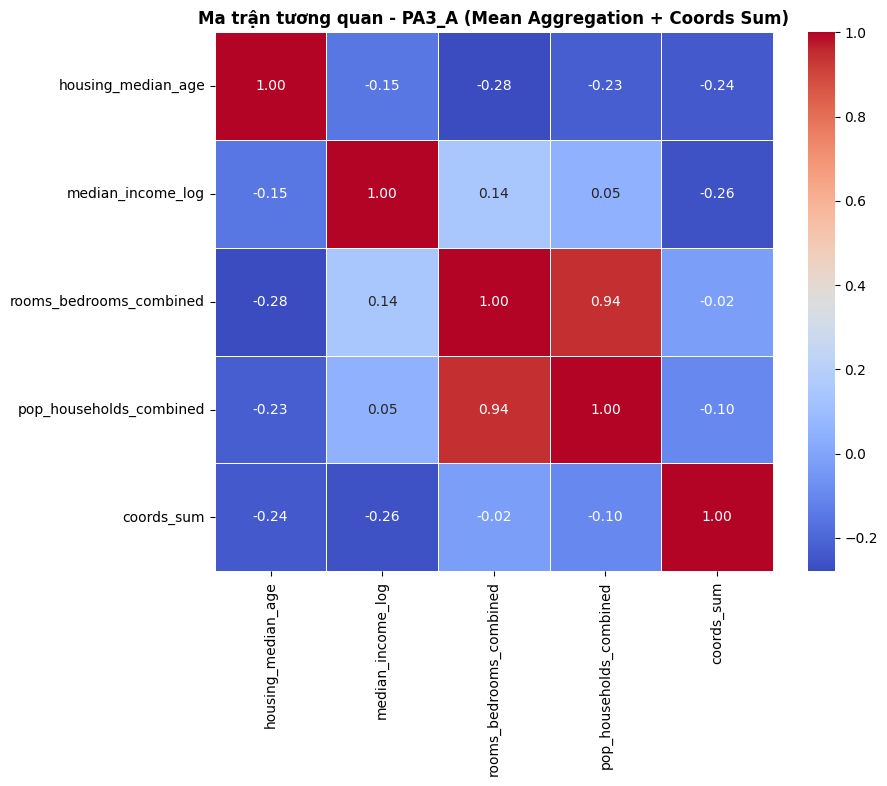

Cột đặc trưng (10): ['housing_median_age', 'median_income_log', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_bedrooms_combined', 'pop_households_combined', 'coords_sum']


,housing_median_age,median_income_log,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_bedrooms_combined,pop_households_combined,coords_sum
14196,0.348490,-0.184340,0.0,0.0,0.0,0.0,1.0,0.615656,0.882927,-0.467268
8267,1.618118,0.170161,0.0,0.0,0.0,0.0,1.0,0.838442,0.614123,-0.553150
17445,-1.952710,0.370597,0.0,0.0,0.0,0.0,1.0,-0.212867,-0.245107,-2.307589
14265,0.586545,-1.258856,0.0,0.0,0.0,0.0,1.0,-0.348288,0.116341,-0.589956
2271,1.142008,0.009915,0.0,1.0,0.0,0.0,0.0,0.144913,-0.188657,1.127677



 SCENARIO: PA3_B (PCA 1D Aggregation + Coords Sum)


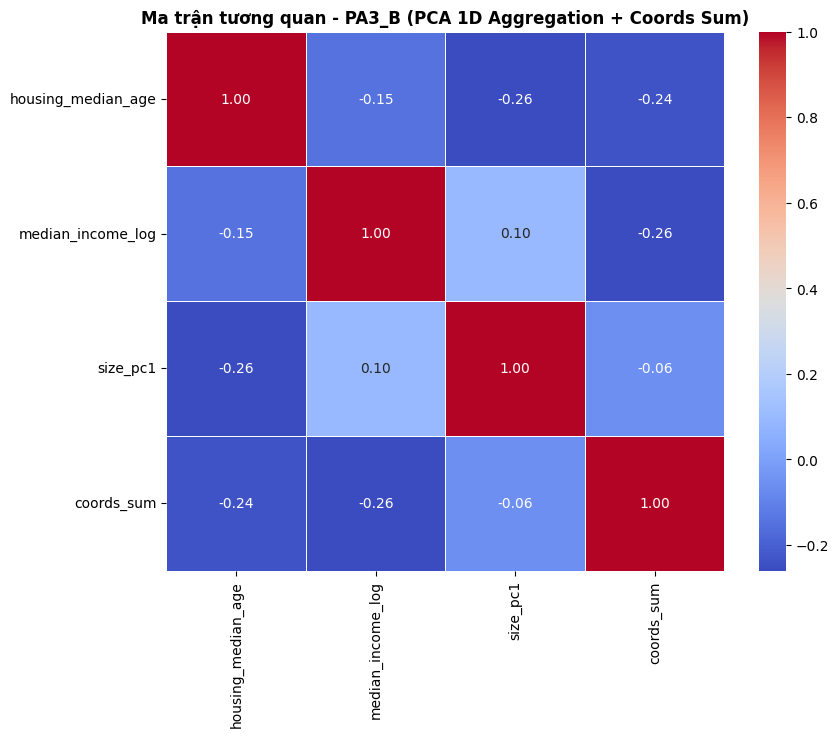

Cột đặc trưng (9): ['housing_median_age', 'median_income_log', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'size_pc1', 'coords_sum']


,housing_median_age,median_income_log,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,size_pc1,coords_sum
14196,0.348490,-0.184340,0.0,0.0,0.0,0.0,1.0,0.757895,-0.467268
8267,1.618118,0.170161,0.0,0.0,0.0,0.0,1.0,0.740032,-0.553150
17445,-1.952710,0.370597,0.0,0.0,0.0,0.0,1.0,-0.231725,-2.307589
14265,0.586545,-1.258856,0.0,0.0,0.0,0.0,1.0,-0.121484,-0.589956
2271,1.142008,0.009915,0.0,1.0,0.0,0.0,0.0,-0.019679,1.127677


In [8]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

scenarios_display = [
    ("PA1 (Base Features - Original)", X_train_pa1),
    ("PA2 (Drop Bedrooms & Households + Coords Sum)", X_train_pa2),
    ("PA3_A (Mean Aggregation + Coords Sum)", X_train_pa3a),
    ("PA3_B (PCA 1D Aggregation + Coords Sum)", X_train_pa3b)
]

for name, df_sc in scenarios_display:
    print(f"\n" + "="*60)
    print(f" SCENARIO: {name}")
    print("="*60)
    
    # Heatmap
    numeric_cols_sc = [col for col in df_sc.columns if col not in ohe_cols]
    corr_matrix = df_sc[numeric_cols_sc].corr()
    
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(f'Ma trận tương quan - {name}', fontsize=12, fontweight='bold')
    plt.show()
    
    # Head table
    print(f"Cột đặc trưng ({len(df_sc.columns)}): {df_sc.columns.tolist()}")
    display(df_sc.head())

## Bước 7: Lưu các kịch bản dữ liệu
Lưu trữ dữ liệu train/test sạch của cả 4 kịch bản phục vụ so sánh mô hình.

In [9]:
import os

processed_dir = "../data/ready_train"

for subfolder, tr, ts in [("PA1", X_train_pa1, X_test_pa1), 
                         ("PA2", X_train_pa2, X_test_pa2), 
                         ("PA3_A", X_train_pa3a, X_test_pa3a), 
                         ("PA3_B", X_train_pa3b, X_test_pa3b)]:
    path = os.path.join(processed_dir, subfolder)
    os.makedirs(path, exist_ok=True)
    tr.to_csv(os.path.join(path, "X_train.csv"), index=False)
    ts.to_csv(os.path.join(path, "X_test.csv"), index=False)
    
    # Save targets
    y_train.to_csv(os.path.join(path, "y_train.csv"), index=False)
    y_test.to_csv(os.path.join(path, "y_test.csv"), index=False)

print(f"Tất cả 4 kịch bản dữ liệu đã được lưu trữ thành công vào {processed_dir}!")

Tất cả 4 kịch bản dữ liệu đã được lưu trữ thành công vào ../data/ready_train!
